In [1]:
import os, sys

sys.path.append(os.path.abspath(os.path.join(os.path.dirname("utils"), "..")))
from module.utils import *
from module.prompt import *
from module.custom_model import *
from module.tools import *
from module.db_agent import *
from module.data_analysis_agent import *
from module.conversaction_agent import *

from typing_extensions import TypedDict

In [2]:
start_langsmith("final_agent_1")

LangSmith 추적을 시작합니다.
[프로젝트명]
final_agent_1


In [3]:
from typing import Annotated, List, Literal, Tuple
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage,
    RemoveMessage,
)
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool
from langchain_core.runnables import RunnableLambda, RunnableWithFallbacks
from langgraph_supervisor import create_supervisor

In [4]:
class State(TypedDict):
    question: Annotated["str", "human request to llm"]
    summary: Annotated[str, "previous messages summarization "]
    messages: Annotated[list, add_messages]
    answer: Annotated["str", "llm generate answer"]

In [5]:
def get_prompt_summary():
    template = """ 
        #System :
        As a summary-only node in LangGraph, you are responsible for summarizing key information by receiving records from previous conversations.  
        Be sure to follow the following rules:

        # Rules:
        1. If the user's requirements are **Analyzing, Comparison, Evaluation, and Modification requests for answers generated by previous LLM:
        - Never summarize the answers generated by the previous LLM and keep the original ****.
        - Combine content by briefly summarizing other surrounding contexts (e.g., discussion process, question background, etc.)

        2. For common conversations (information queries, descriptions, requests, etc.) that do not meet the above conditions:
        - Only important contents are summarized in **sentence form.**.
        - Remove unnecessary detailed descriptions, duplicate sentences, and text repeated in context.
        - It is described focusing on facts, and opinions or expressions of emotions are excluded.

        3. Finally, the summary is written in Korean.

        # Enter :
        - User Request : {question}
        - LLM's previous answer : {answer}
        - All previous conversations : {messages}
        - Summary of the conversation : {summary}
    """
    return ChatPromptTemplate.from_template(template)

In [6]:
def summary_node(state: State):
    """
    이전 모든 대화 내용중 핵심을 포함하여 요약하기위한 노드
    messages 가 6개 이상인 경우 summarization 수행
    """
    question = state.get('question', '')
    messages = state.get('messages', [])
    answer = state.get('answer', '')
    summary = state.get('summary', '')
    chain = get_prompt_summary()|get_gemini()
    response = chain.invoke({'question':question,'messages':messages,'answer':answer,'summary':summary})
    # 오래된 메시지 삭제
    delete_messages = [RemoveMessage(id=m.id) for m in state["messages"][:-2]]
    # 요약 정보 반환
    return {"summary": response.content, "messages": delete_messages}


def supervisor_node(state: State):
    """
    두개의 에이전트를 자율적으로 선택하여 사용하는 관리자에이전트 구조
    """
    summary = state.get("summary", "")
    question = state["question"]
    content = f"Previous Conversations: {summary} \n Human Request : {question}"
    db = get_db_agent()
    conversation = get_conversation_agent()
    data_analysis = get_data_analysis_agent()
    supervisor = create_supervisor(
        model=get_gpt(),
        agents=[db, conversation, data_analysis],
        prompt=(
            "You are a supervisor managing three agents:\n"
            "- db_agent: assign database select,insert,delete,update tasks\n"
            "- conversation_agent: assign normal conversaction and no use agent\n"
            "- data_analysis_agent: Agents that generate and run Python code for data analysis\n"
            "# Important : you must final answer is Korean\n"
        ),
        add_handoff_back_messages=True,
        output_mode="full_history",
        
    ).compile()
    inputs = {"messages": [{"role": "user", "content": content}]}
    result = supervisor.invoke(inputs, {"recursion_limit": 10})
    messages = result["messages"]
    return {"messages": messages, "answer": messages[-1].content}


In [7]:
state_graph = StateGraph(State)
state_graph.add_node("summary_node", summary_node)
state_graph.add_node("supervisor_node", supervisor_node)


state_graph.add_edge(START, "summary_node")
state_graph.add_edge("summary_node", "supervisor_node")
state_graph.add_edge("supervisor_node", END)

cp = get_check_pointer()
graph = state_graph.compile(checkpointer=cp)

In [8]:
# visualize_graph(graph)

In [9]:
config = get_runnable_config(recursion_limit=10, thread_id=get_random_uuid())

question = "2010년 각 월별 Jazz,Rock 판매량만 가져와"
inputs = {"question": question, "messages": question}

for event in graph.stream(inputs, config=config, stream_mode="values"):
    pass

In [10]:
snapshot1 = graph.get_state(config)
# parse_messages(first_snapshot.values["messages"])
snapshot1.values
# parse_messages(snapshot1.values['messages'])

{'question': '2010년 각 월별 Jazz,Rock 판매량만 가져와',
 'summary': '2010년 각 월별 Jazz, Rock 장르의 판매량을 요청했습니다.',
 'messages': [HumanMessage(content='2010년 각 월별 Jazz,Rock 판매량만 가져와', additional_kwargs={}, response_metadata={}, id='a7062a13-885e-4dcb-821a-99b0e75cc165'),
  HumanMessage(content='Previous Conversations: 2010년 각 월별 Jazz, Rock 장르의 판매량을 요청했습니다. \n Human Request : 2010년 각 월별 Jazz,Rock 판매량만 가져와', additional_kwargs={}, response_metadata={}, id='68bb7fb5-055d-4251-ba2f-0efaab45f65e'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_gdEhinYmPMYnS2jFbtUcNRWP', 'function': {'arguments': '{}', 'name': 'transfer_to_db_agent'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 186, 'total_tokens': 198, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model

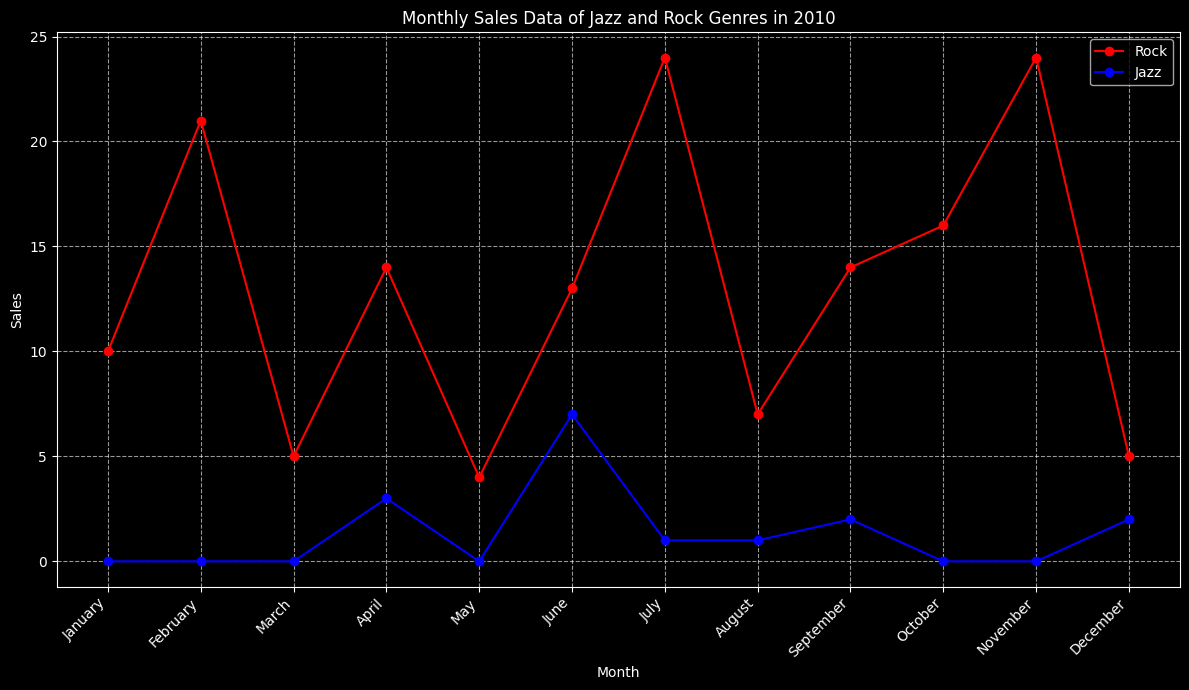

In [11]:
question = "가져온 정보를 활용하여 차트로 분석해줘"
inputs = {"question": question, "messages": question}

for event in graph.stream(inputs, config=config, stream_mode="values"):
    pass

In [12]:
snapshot2 = graph.get_state(config)
# parse_messages(first_snapshot.values["messages"])
snapshot2.values['answer']

'2010년 각 월별 Jazz와 Rock 장르의 판매량 데이터를 기반으로 작성한 차트는 다음과 같습니다.\n\n- x축은 1월부터 12월까지의 월별로 구성되어 있습니다.\n- y축은 판매량을 나타냅니다.\n- 빨간색 선은 Rock 장르의 월별 판매량을 표시하며, 파란색 선은 Jazz 장르의 월별 판매량을 표시합니다.\n- Jazz는 일부 월에만 판매량이 기록되어 있어 0으로 표시된 월도 있습니다.\n- 차트는 각 장르의 판매 추이를 한눈에 비교할 수 있도록 선 그래프로 시각화되었습니다.\n\n이 차트를 통해 Rock 장르는 전반적으로 높은 판매량을 유지하고 있으며, 특히 7월과 11월에 판매량이 크게 증가한 것을 확인할 수 있습니다. Jazz는 4월, 6월, 7월, 8월, 9월, 12월에 판매가 있었고, 그 외의 월에는 판매량이 없거나 매우 적은 편임을 알 수 있습니다.\n\n필요하시면 차트 이미지나 추가 분석도 도와드리겠습니다.'

In [13]:
# question = "2010년 각 월별 Jazz,Rock 판매량만 가져와"
# inputs = {"question": question, "messages": question}

# for event in graph.stream(inputs, config=config, stream_mode="values"):
#     pass

# snapshot3 = graph.get_state(config)
# # parse_messages(first_snapshot.values["messages"])
# snapshot3.values

In [14]:
# snapshot3.values["answer"]
# parse_messages(snapshot3.values['messages'])